In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (5572, 2)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
print(df["label"].value_counts(normalize=True) * 100)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


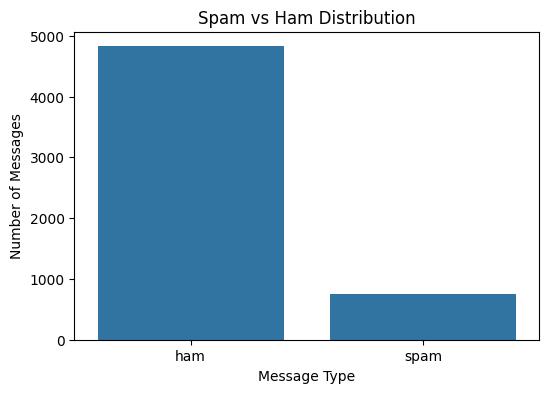

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [8]:
stop_words = set(stopwords.words("english"))

In [9]:
def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [10]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that can be used by machine learning models.

It measures how important a word is in a document compared with how frequently that word appears across the entire dataset.

A word receives a higher TF-IDF value when it is frequent in a particular message but relatively uncommon across other messages.

In [11]:
X = df["clean_message"]
y = df["label"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4457, 7411)
Testing shape: (1115, 7411)


In [17]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [19]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, pos_label="spam")
recall_nb = recall_score(y_test, y_pred_nb, pos_label="spam")
f1_nb = f1_score(y_test, y_pred_nb, pos_label="spam")

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1-score :", f1_nb)

Naive Bayes Results
-------------------
Accuracy : 0.9650224215246637
Precision: 1.0
Recall   : 0.738255033557047
F1-score : 0.8494208494208494


In [20]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115



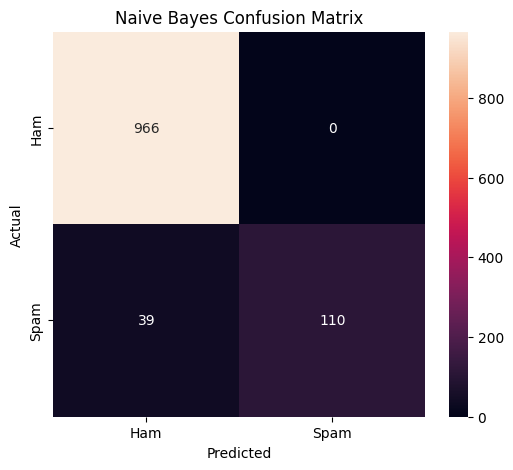

In [21]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [25]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="spam")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="spam")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="spam")

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-score :", f1_lr)


Logistic Regression Results
---------------------------
Accuracy : 0.9659192825112107
Precision: 1.0
Recall   : 0.7449664429530202
F1-score : 0.8538461538461538


In [26]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



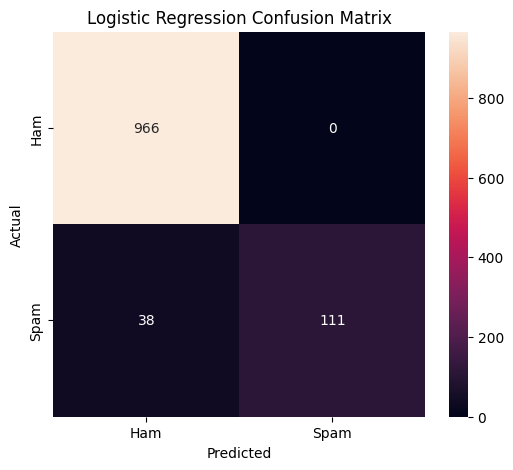

In [27]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_nb, accuracy_lr],
    "Precision": [precision_nb, precision_lr],
    "Recall": [recall_nb, recall_lr],
    "F1-Score": [f1_nb, f1_lr]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.965022,1.0,0.738255,0.849421
1,Logistic Regression,0.965919,1.0,0.744966,0.853846


## Why is Recall Important in Spam Detection?

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the model.

A low recall means that many spam messages are incorrectly classified as legitimate messages (ham). This can allow unwanted or potentially harmful messages to reach the user's inbox.

Therefore, a high recall is desirable because we want the model to detect as many spam messages as possible.

In [29]:
!pip install wordcloud

In [30]:
from wordcloud import WordCloud

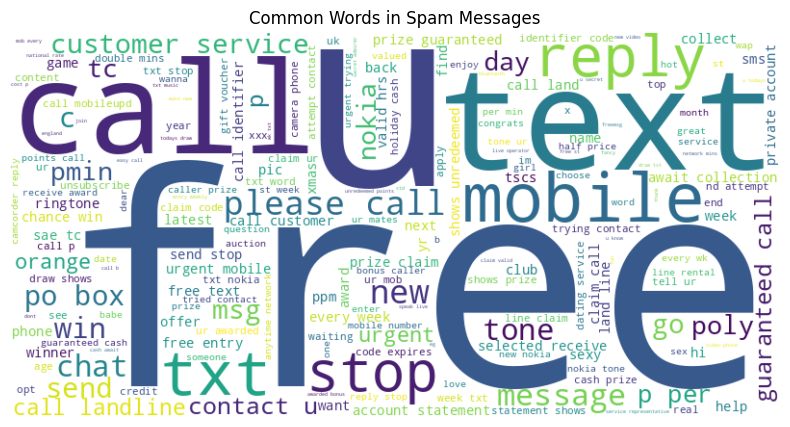

In [31]:
spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.show()

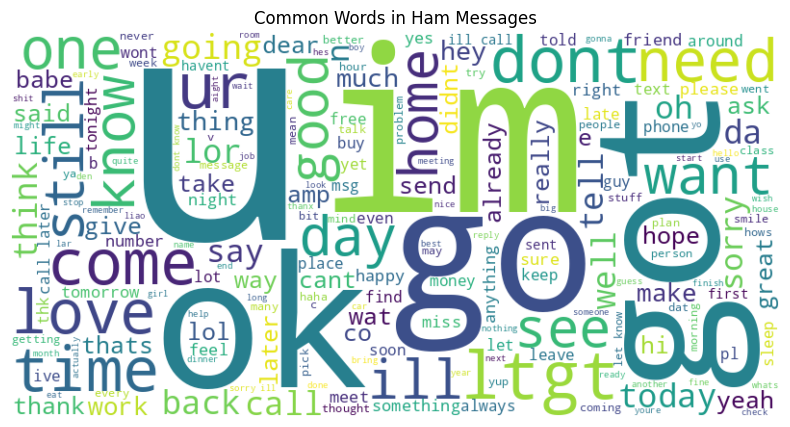

In [32]:
ham_text = " ".join(
    df[df["label"] == "ham"]["clean_message"]
)

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Ham Messages")
plt.show()

## Conclusion

In this project, a machine learning system was developed to classify messages as spam or ham.

The dataset was cleaned using text preprocessing techniques such as lowercase conversion, punctuation removal, and stopword removal.

TF-IDF was then used to convert the text into numerical features.

Two classification models were trained and evaluated: Multinomial Naive Bayes and Logistic Regression.

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

Recall is especially important in spam detection because missing actual spam messages can allow unwanted messages to reach the user's inbox.

The results show that machine learning and NLP techniques can effectively be used to automatically detect spam messages.